In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import os
from collections import Counter

In [2]:
GWAS_SNPs_df = pd.read_csv("../hg38_combined_unique_HCM_SNPs.csv", header=None)
GWAS_SNPs_df.columns = ["SNP"]

In [3]:
num_SNPs = GWAS_SNPs_df.shape[0]
print(num_SNPs)

68


In [3]:
SNP_names = GWAS_SNPs_df['SNP']

all_res_list = list()

for SNP in SNP_names:

    SNP_res_path = "LD_results_EUR/" + SNP + ".ld"

    if os.path.exists(SNP_res_path):
        SNP_results_df = pd.read_csv("LD_results_EUR/" + SNP + ".ld", delim_whitespace=True)
        all_res_list.append(SNP_results_df)

all_res_df = pd.concat(all_res_list).reset_index(drop=True)

### These are all SNPs within 10kb, we will filter this to those with R^2 > 0.2

In [4]:
all_res_df

,CHR_A,BP_A,SNP_A,CHR_B,BP_B,SNP_B,R2
0,1,2212668,1:2212668:A:G,1,2124676,1:2124676:A:G,0.275521
1,1,2212668,1:2212668:A:G,1,2212668,1:2212668:A:G,1.000000
2,1,2212668,1:2212668:A:G,1,2213543,1:2213543:G:T,0.363901
3,1,2212668,1:2212668:A:G,1,2215707,1:2215707:T:C,0.311708
4,1,2212668,1:2212668:A:G,1,2224923,1:2224923:A:G,0.321696
...,...,...,...,...,...,...,...
20090,22,40330745,22:40330745:C:T,22,40670819,22:40670819:A:AAAAT,0.479930
20091,22,40330745,22:40330745:C:T,22,40671006,22:40671006:G:T,0.527362
20092,22,40330745,22:40330745:C:T,22,40685485,22:40685485:C:T,0.242428
20093,22,40330745,22:40330745:C:T,22,40697122,22:40697125:CA:C,0.215981


In [8]:
all_res_df['distance'] = np.abs(all_res_df['BP_B'] - all_res_df['BP_A'])

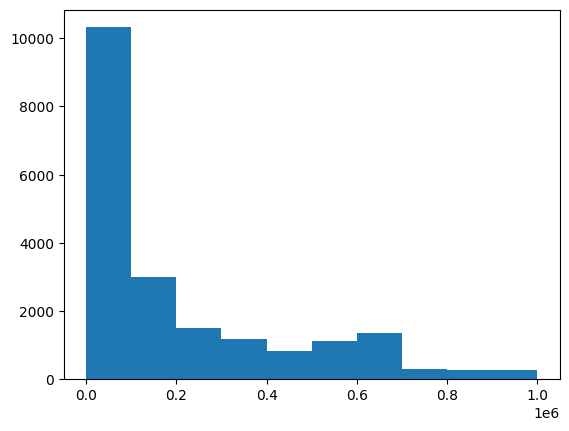

In [9]:
plt.hist(all_res_df['distance'])
plt.show()

In [10]:
all_res_df['R2'].min()

0.200014

In [12]:
# just use the most permissive filter
LD_SNP_df = all_res_df[all_res_df['R2'] > 0.8].reset_index(drop=True)
print(LD_SNP_df.shape)

(6151, 8)


In [13]:
LD_SNP_df

,CHR_A,BP_A,SNP_A,CHR_B,BP_B,SNP_B,R2,distance
0,1,2212668,1:2212668:A:G,1,2212668,1:2212668:A:G,1.000000,0
1,1,6203732,1:6203732:A:G,1,6202171,1:6202171:A:T,0.985316,1561
2,1,6203732,1:6203732:A:G,1,6203732,1:6203732:A:G,1.000000,0
3,1,16014384,1:16014384:T:G,1,15970694,1:15970694:G:A,0.821060,43690
4,1,16014384,1:16014384:T:G,1,15971243,1:15971243:GA:G,0.806016,43141
...,...,...,...,...,...,...,...,...
6146,22,23819530,22:23819530:C:T,22,23839465,22:23839465:A:G,0.826250,19935
6147,22,40330745,22:40330745:C:T,22,40330745,22:40330745:C:T,1.000000,0
6148,22,40330745,22:40330745:C:T,22,40330758,22:40330758:A:G,0.987171,13
6149,22,40330745,22:40330745:C:T,22,40359476,22:40359476:CT:C,0.831782,28731


In [15]:
LD_SNP_df['lead_SNP'] = ( "chr" +  LD_SNP_df['CHR_A'].astype(str) + ":" +
                         LD_SNP_df['BP_A'].astype(str) +  "-" + LD_SNP_df['BP_A'].astype(str) )

### Merge with the prioritized gene from the GWAS study

In [16]:
GWAS_summary_df = pd.read_csv("../Tadros_GWAS_hits_GRCh38.bed", delimiter = "\t", header=None)
GWAS_summary_df.columns = ["chr", "start", "end", "rsID", "prioritized_gene"]
GWAS_summary_df['lead_SNP'] = (GWAS_summary_df['chr'].astype(str) + ":" +
                               GWAS_summary_df['start'].astype(str) + "-" +
                               GWAS_summary_df['end'].astype(str)
                              )

In [17]:
new_LD_SNP_df = LD_SNP_df.merge(GWAS_summary_df[["lead_SNP", "prioritized_gene"]])

In [18]:
new_LD_SNP_df.to_csv("04_lead_and_LD_SNPs.csv", index=False)
new_LD_SNP_df.head()

,CHR_A,BP_A,SNP_A,CHR_B,BP_B,SNP_B,R2,distance,lead_SNP,prioritized_gene
0,1,2212668,1:2212668:A:G,1,2212668,1:2212668:A:G,1.000000,0,chr1:2212668-2212668,FAAP20/SKI
1,1,6203732,1:6203732:A:G,1,6202171,1:6202171:A:T,0.985316,1561,chr1:6203732-6203732,RNF207
2,1,6203732,1:6203732:A:G,1,6203732,1:6203732:A:G,1.000000,0,chr1:6203732-6203732,RNF207
3,1,16014384,1:16014384:T:G,1,15970694,1:15970694:G:A,0.821060,43690,chr1:16014384-16014384,HSPB7
4,1,16014384,1:16014384:T:G,1,15971243,1:15971243:GA:G,0.806016,43141,chr1:16014384-16014384,HSPB7


### Save in a bed format

In [19]:
LD_SNP_bed_df = LD_SNP_df[["CHR_A", "BP_B", "BP_B", "SNP_A"]].copy()
LD_SNP_bed_df['CHR_A'] = "chr" + LD_SNP_bed_df['CHR_A'].astype(str)

In [20]:
LD_SNP_bed_df

,CHR_A,BP_B,BP_B,SNP_A
0,chr1,2212668,2212668,1:2212668:A:G
1,chr1,6202171,6202171,1:6203732:A:G
2,chr1,6203732,6203732,1:6203732:A:G
3,chr1,15970694,15970694,1:16014384:T:G
4,chr1,15971243,15971243,1:16014384:T:G
...,...,...,...,...
6146,chr22,23839465,23839465,22:23819530:C:T
6147,chr22,40330745,40330745,22:40330745:C:T
6148,chr22,40330758,40330758,22:40330745:C:T
6149,chr22,40359476,40359476,22:40330745:C:T


In [21]:
LD_SNP_bed_df.to_csv("04_lead_and_LD_SNPs.bed", sep = "\t", header=False, index=False)

### Calculate the max distance between a lead SNP and another SNP with R^2>0.2

In [22]:
distances = np.abs(LD_SNP_df['BP_B'] - LD_SNP_df['BP_A'])
np.max(distances)

938030